# 贝叶斯网络（Bayesian Network）


## 1. 什么是贝叶斯网络？

贝叶斯网络是一种基于概率图模型的方法，
用于描述变量之间的概率依赖关系。


它由两部分组成：

1. 有向无环图（DAG, Directed Acyclic Graph）

2. 条件概率表（CPT, Conditional Probability Table）


其中：

- 节点表示随机变量
- 有向边表示变量之间的依赖关系
- CPT表示变量在父节点条件下的概率分布





1.使用 sklearn 自带：

Breast Cancer Wisconsin数据集

In [2]:
from sklearn.datasets import load_breast_cancer

import pandas as pd
import numpy as np


data = load_breast_cancer()


X = data.data
y = data.target


print(X.shape)
print(y.shape)

(569, 30)
(569,)


2.选择如下的特征：
radius	肿瘤半径
texture	纹理
perimeter	周长
area	面积
smoothness	平滑度
diagnosis	诊断结果

In [32]:
feature_map = {

    "mean radius":"平均半径",

    "mean texture":"平均纹理",

    "mean perimeter":"平均周长",

    "mean area":"平均面积",

    "mean smoothness":"平均平滑度"

}
features = [
    "平均半径",
    "平均纹理",
    "平均周长",
    "平均面积",
    "平均平滑度"
]


X_selected = pd.DataFrame(
    X[:,[
        0,
        1,
        2,
        3,
        4
    ]],
    columns=features
)


X_selected["诊断结果"]=y


X_selected.head()

,平均半径,平均纹理,平均周长,平均面积,平均平滑度,诊断结果
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0


诊断结果

0 = malignant
恶性

1 = benign
良性

3.离散化:分箱，如果不离散那贝叶斯网络的CPT会快速膨胀，规模会急剧增大，本例中箱数为3，即把平均半径分为3类：小中大。

In [33]:
from sklearn.preprocessing import KBinsDiscretizer


encoder = KBinsDiscretizer(
    n_bins=3,
    encode="ordinal",
    strategy="quantile"
)


X_disc = encoder.fit_transform(
    X_selected.iloc[:,:5]
)


X_disc = pd.DataFrame(
    X_disc,
    columns=features
)


X_disc["诊断结果"] = y


X_disc.head()

,平均半径,平均纹理,平均周长,平均面积,平均平滑度,诊断结果
0,2.0,0.0,2.0,2.0,2.0,0
1,2.0,1.0,2.0,2.0,0.0,0
2,2.0,2.0,2.0,2.0,2.0,0
3,0.0,1.0,0.0,0.0,2.0,0
4,2.0,0.0,2.0,2.0,1.0,0


4.观察相关性（肿瘤越大：
半径越大
周长越大
面积越大）

In [37]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']  # 黑体
plt.rcParams['axes.unicode_minus'] = False   # 解决负号显示问题

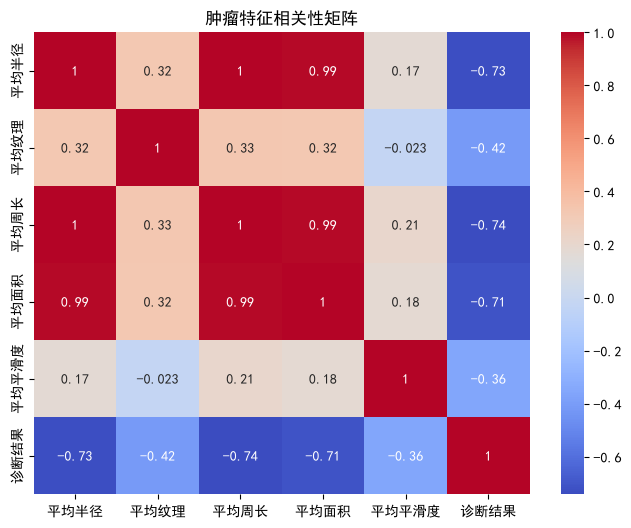

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8,6))


sns.heatmap(
    X_selected.corr(),
    annot=True,
    cmap="coolwarm",
    xticklabels=X_selected.columns,
    yticklabels=X_selected.columns
)


plt.title(
    "肿瘤特征相关性矩阵"
)


plt.show()

5.设计贝叶斯网络结构（人工指定（专家知识建模）/自动结构学习（数据驱动））
人工指定：
        diagnosis

        /     \

       ↓       ↓

   radius    texture


       ↓

   perimeter

       ↓

      area


In [39]:
from pgmpy.models import DiscreteBayesianNetwork



model = DiscreteBayesianNetwork(
    [

        ("诊断结果","平均半径"),

        ("诊断结果","平均纹理"),


        ("平均半径","平均周长"),


        ("平均周长","平均面积"),


        ("诊断结果","平均平滑度")

    ]
)

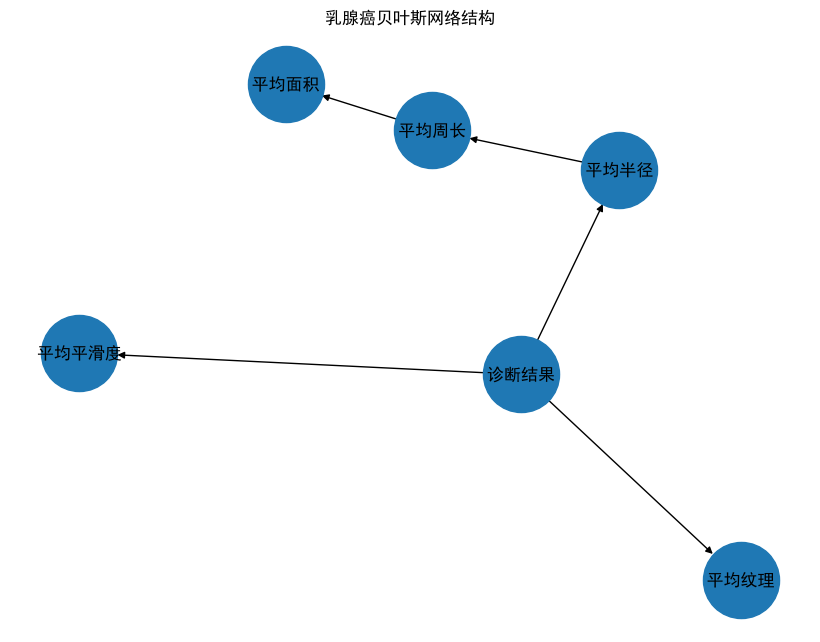

In [40]:
import networkx as nx
import matplotlib.pyplot as plt


plt.figure(figsize=(8,6))


G = nx.DiGraph()


G.add_edges_from(
    model.edges()
)


pos = nx.spring_layout(
    G,
    seed=42
)


nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000,
    font_size=12,
    arrows=True
)


plt.title(
    "乳腺癌贝叶斯网络结构"
)


plt.show()

6.学习CPT参数

In [41]:
from pgmpy.parameter_estimator import DiscreteMLE


estimator = DiscreteMLE()


model.fit(
    X_disc,
    estimator=estimator
)
for cpd in model.get_cpds():
    print(cpd)
    print("----------------")

+---------+----------+
| 诊断结果(0) | 0.372583 |
+---------+----------+
| 诊断结果(1) | 0.627417 |
+---------+----------+
----------------
+-----------+---------------------+---------------------+
| 诊断结果      | 诊断结果(0)             | 诊断结果(1)             |
+-----------+---------------------+---------------------+
| 平均半径(0.0) | 0.02830188679245283 | 0.5126050420168067  |
+-----------+---------------------+---------------------+
| 平均半径(1.0) | 0.18396226415094338 | 0.42296918767507    |
+-----------+---------------------+---------------------+
| 平均半径(2.0) | 0.7877358490566038  | 0.06442577030812324 |
+-----------+---------------------+---------------------+
----------------
+-----------+---------------------+---------------------+
| 诊断结果      | 诊断结果(0)             | 诊断结果(1)             |
+-----------+---------------------+---------------------+
| 平均纹理(0.0) | 0.09905660377358491 | 0.47058823529411764 |
+-----------+---------------------+---------------------+
| 平均纹理(1.0) | 0.330188679245283   | 0.3


+---------+----------+
| 诊断结果(0) | 0.372583 |
+---------+----------+
| 诊断结果(1) | 0.627417 |
+---------+----------+表示先验概率：P(诊断结果)，P(0)=0.372583,P(1)=0.627417


+-----------+---------------------+---------------------+
| 诊断结果      | 诊断结果(0)             | 诊断结果(1)             |
+-----------+---------------------+---------------------+
| 平均半径(0.0) | 0.02830188679245283 | 0.5126050420168067  |
+-----------+---------------------+---------------------+
| 平均半径(1.0) | 0.18396226415094338 | 0.42296918767507    |
+-----------+---------------------+---------------------+
| 平均半径(2.0) | 0.7877358490566038  | 0.06442577030812324 |
+-----------+---------------------+---------------------+
表示条件概率：P(平均半径|诊断结果)

前面只是为了学习条件概率，还没有实现分类器的建模，接下来才是实现分类器的建模与封装

7.划分训练集与测试集

In [43]:
from sklearn.model_selection import train_test_split


train_data, test_data = train_test_split(
    X_disc,
    test_size=0.2,
    random_state=42,
    stratify=X_disc["诊断结果"]
)


print(train_data.shape)
print(test_data.shape)

(455, 6)
(114, 6)


8.重新建立训练网格（仅用训练集学习CPT）

In [44]:
from pgmpy.models import DiscreteBayesianNetwork


bn_model = DiscreteBayesianNetwork(

[
("诊断结果","平均半径"),

("平均半径","平均周长"),

("平均周长","平均面积"),

("诊断结果","平均纹理"),

("诊断结果","平均平滑度")
]

)

In [46]:
from pgmpy.parameter_estimator import DiscreteMLE


estimator = DiscreteMLE()
bn_model.fit(
    train_data,
    estimator=estimator
)

9.建立贝叶斯网络分类器

In [47]:
from pgmpy.inference import VariableElimination


infer = VariableElimination(
    bn_model
)

In [48]:
def bayes_network_predict(row):

    evidence = {

        "平均半径": int(row["平均半径"]),

        "平均纹理": int(row["平均纹理"]),

        "平均周长": int(row["平均周长"]),

        "平均面积": int(row["平均面积"]),

        "平均平滑度": int(row["平均平滑度"])

    }


    result = infer.query(

        variables=["诊断结果"],

        evidence=evidence

    )


    return np.argmax(
        result.values
    )

10.测试集测试

In [49]:
y_true = test_data["诊断结果"]


y_pred = []


for _,row in test_data.iterrows():

    y_pred.append(
        bayes_network_predict(row)
    )


y_pred=np.array(y_pred)

In [50]:
from sklearn.metrics import accuracy_score


acc = accuracy_score(
    y_true,
    y_pred
)


print(
    "贝叶斯网络准确率:",
    acc
)

贝叶斯网络准确率: 0.8859649122807017


离散化之后，114个数据点全部集中在几个点上（离散空间仅3*3），即分为了五组数据点，所以下面的对比只有五个点

In [59]:
import pandas as pd
import matplotlib.pyplot as plt


result = pd.DataFrame({

    "真实类别":y_true.values,

    "预测类别":y_pred

})


result.head()

,真实类别,预测类别
0,0,0
1,1,1
2,0,0
3,1,0
4,0,0


11.混淆矩阵与可视化

In [51]:
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(
    y_true,
    y_pred
)


print(cm)

[[37  5]
 [ 8 64]]


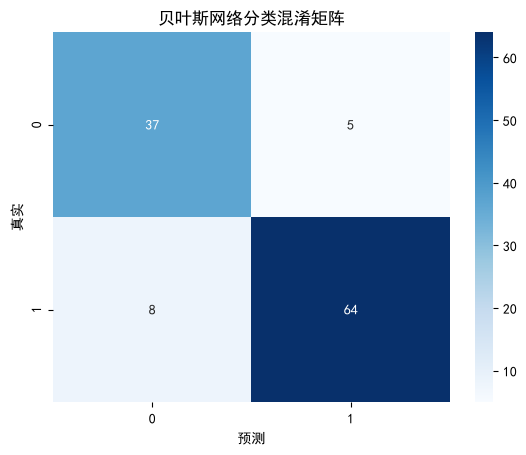

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)


plt.xlabel("预测")
plt.ylabel("真实")

plt.title(
    "贝叶斯网络分类混淆矩阵"
)

plt.show()

12.与朴素贝叶斯分类器比较

In [53]:
from sklearn.naive_bayes import CategoricalNB


nb = CategoricalNB()


nb.fit(

train_data.iloc[:,:5],

train_data["诊断结果"]

)


nb_pred = nb.predict(
    test_data.iloc[:,:5]
)


print(
"朴素贝叶斯:",
accuracy_score(
    y_true,
    nb_pred
)
)

朴素贝叶斯: 0.868421052631579
